# Activist radar: fresh 13D filings across the whole market

A Schedule 13D means someone crossed 5% ownership with activist intent
(13G is the passive version). Beneficial ownership is one of the few
families that allows market-wide date scans, so you can watch every new
activist stake in one query, no ticker list required. Filings are
indexed under both parties' ciks, so the first step dedupes to one row
per filing.

Needs `pandas` and `matplotlib`, and a free API key in
`THREESPREAD_API_KEY` ([signup](https://3spread.com/auth/signup)).

In [1]:
import datetime as dt

import pandas as pd

from py3spread import Client

client = Client()

end = dt.date.today()
start = end - dt.timedelta(days=60)

df = pd.DataFrame(client.beneficial_ownership.iter(
    schedule_type="13D", accepted_start=str(start), accepted_end=str(end)))

# each filing is indexed under both the activist's and the issuer's cik,
# so keep one row per accession, preferring the activist-side row
def norm(s):
    return "".join(str(s).upper().split())

df["self_side"] = [norm(f) == norm(i) for f, i in zip(df["filer_name"], df["issuer_name"])]
df = (df.sort_values("self_side").drop_duplicates(subset="accession_num")
      .drop(columns="self_side").reset_index(drop=True))
originals = df[~df["is_amendment"]].reset_index(drop=True)
print(f"{len(df)} 13D filings in 60 days, {len(originals)} original (new stakes)")
originals[["accepted_time", "issuer_name", "filer_name", "event_date"]].head(10)

865 13D filings in 60 days, 177 original (new stakes)


,accepted_time,issuer_name,filer_name,event_date
0,2026-06-01T00:00:00,"Dermata Therapeutics, Inc.",Van Hoose Kyri K.,2026-05-27
1,2026-05-12T00:00:00,West Enclave Merger Corp.,WEST ENCLAVE SPONSOR LLC,2026-05-01
2,2026-06-01T00:00:00,"Red Violet, Inc.",Dubner Derek,2026-06-01
3,2026-05-12T00:00:00,ChronoScale Corporation,ChronoScale Corp,2026-05-05
4,2026-05-28T00:00:00,"Datacentrex, Inc.","American Ventures LLC, Series VII USDAE",2026-05-28
5,2026-05-29T00:00:00,Brera Holdings PLC,Sade Ron,2026-05-21
6,2026-05-29T00:00:00,Research Alliance Corporation III,Research Alliance Corp III,2026-05-21
7,2026-05-13T00:00:00,5C Lending Partners Corp.,Qatar Investment Authority,2026-03-20
8,2026-06-08T00:00:00,OceanFirst Financial Corp.,OCEANFIRST FINANCIAL CORP,2026-06-01
9,2026-06-05T00:00:00,StepStone Private Infrastructure Fund,StepStone Group LP,2023-08-17


## Filing volume

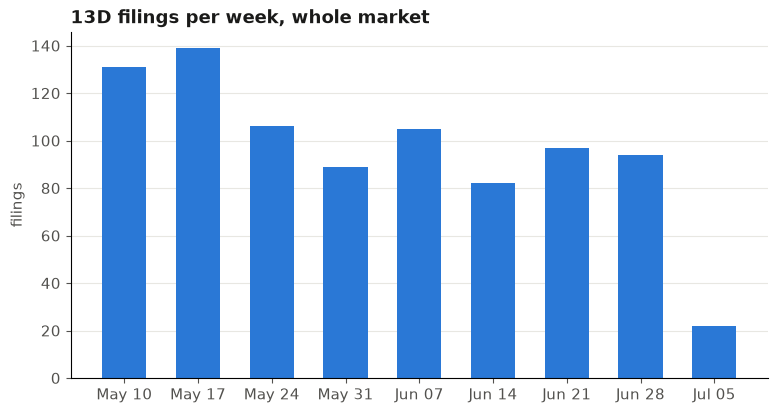

In [2]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (9, 4.5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#e8e7e2",
    "grid.linewidth": 0.8,
    "axes.axisbelow": True,
    "font.size": 11,
    "text.color": "#1a1a19",
    "axes.labelcolor": "#52514e",
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
})
BLUE = "#2a78d6"
INK = "#52514e"


weekly = (df.assign(t=pd.to_datetime(df["accepted_time"]))
          .set_index("t").resample("W").size())

fig, ax = plt.subplots()
ax.bar(weekly.index.strftime("%b %d"), weekly.values, color=BLUE, width=0.6)
ax.set_title("13D filings per week, whole market", loc="left", fontweight="bold")
ax.set_ylabel("filings")
ax.grid(axis="x", visible=False)
plt.show()

A beta honesty note before reading that chart as market signal: weekly
counts reflect what has been ingested so far, not necessarily what was
filed. `client.coverage.intake(period="weekly")` returns the intake
histogram; verify against it before narrating dips or surges.


## Most active filers in the window

No extra requests needed, it all falls out of the scan:

In [3]:
(df.groupby("filer_name")
   .agg(filings=("filing_id", "count"), companies=("issuer_name", "nunique"))
   .sort_values("filings", ascending=False)
   .head(10))

,filings,companies
filer_name,,
"Saba Capital Management, L.P.",13,9
FRANKLIN RESOURCES INC,11,3
"Hyperscale Data, Inc.",8,2
"RA CAPITAL MANAGEMENT, L.P.",8,4
"Tether Global Investments Fund, S.I.C.A.F., S.A.",7,5
Qatar Investment Authority,6,4
ORBIMED ADVISORS LLC,6,4
Al Shams Investments LTD,6,1
Fairmount Funds Management LLC,5,5


## Anatomy of the newest stake

Full filing detail includes each reporting person's stake size, percent
of class, voting power split, and source of funds.

In [4]:
newest = originals.iloc[0]
detail = client.beneficial_ownership.get(newest["filing_id"])
print(f"{detail['issuer_name']}  |  filed {detail['accepted_time'][:10]}"
      f"  |  event date {detail['event_date']}")
print(f"source: {detail['source_url']}")

pd.DataFrame(detail["reporting_persons"])[[
    "names", "reporting_person_type", "percent_of_class", "aggregate_amount",
    "sole_voting_power", "shared_voting_power", "source_of_funds",
]]

Dermata Therapeutics, Inc.  |  filed 2026-06-01  |  event date 2026-05-27
source: https://www.sec.gov/Archives/edgar/data/1860885/000149315226026642/0001493152-26-026642-index.htm


,names,reporting_person_type,percent_of_class,aggregate_amount,sole_voting_power,shared_voting_power,source_of_funds
0,Kyri K. Van Hoose,IN,9.0000,384352.0000,384352.0000,0.0000,PF


## Where to take it

- watch `13D/A` amendments on a position to track accumulation or exit
- join `issuer_cusip` (normalize it first, see
  `insider_vs_institutions.ipynb`) into the 13F holdings stream to see
  which institutions are on the other side
- poll `client.changes.iter("beneficial_ownership")` to run this as a
  live feed instead of a 60 day lookback